In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from functions import log_transform_abundance, pivot_by_protein, filter_high_quality

# === 1. Load and log-transform training data (no mouse kidney) ===
df = pd.read_parquet("all_organisms_filtered_without_M.musculus_KIDNEY.parquet", engine="fastparquet")

df = log_transform_abundance(df)

# === 2. Pivot by UniprotAccession for M. musculus ===
mouse_df = pivot_by_protein(df, organism="M.musculus")

# === 3. Load withheld mouse kidney data ===
# Assume this file was just provided
kidney_test = pd.read_csv("train_added_M.musculus_KIDNEY_data.csv")  # Update if filename differs
kidney_test = log_transform_abundance(kidney_test)
kidney_test = pivot_by_protein(kidney_test, organism="M.musculus")

# === 4. Merge training + test (keeping only common UniprotAccessions) ===
# Inner join to keep only the 12,129 proteins
merged = mouse_df.join(kidney_test[['KIDNEY']], how='inner', lsuffix='', rsuffix='_KIDNEY')

# === 6. Train/test split using KIDNEY as target ===
X = merged.drop(columns="KIDNEY")

# === Load IDs from CSV ===
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Extract UniprotAccessions
train_ids = train_df["UniprotAccession"]
test_ids = test_df["UniprotAccession"]

# === Filter IDs to those that exist in X ===
train_ids_filtered = train_ids[train_ids.isin(X.index)]
test_ids_filtered = test_ids[test_ids.isin(X.index)]

# === Subset X and y to match ===
X_train = X.loc[train_ids_filtered]
y_train = train_df.set_index("UniprotAccession").loc[train_ids_filtered]["KIDNEY"]

X_test = X.loc[test_ids_filtered]
y_test = test_df.set_index("UniprotAccession").loc[test_ids_filtered]["KIDNEY"]

# 1. Map UniprotAccession to nog_id (M.musculus only)
mouse_nog_map = df[df["organism_name"] == "M.musculus"][["UniprotAccession", "nog_id"]].drop_duplicates().set_index("UniprotAccession")

# 2. Get human kidney abundances by nog_id (log10 transformed & averaged)
human_kidney_df = df[
    (df["organism_name"] == "H.sapiens") & 
    (df["sample_organ"] == "KIDNEY")
][["nog_id", "abundance"]].copy()
human_kidney_df["abundance"] = np.log10(human_kidney_df["abundance"])
human_kidney_mean = human_kidney_df.groupby("nog_id")["abundance"].mean()

# 3. Add nog_id to X_train and X_test
X_train = X_train.join(mouse_nog_map, how="left")
X_test = X_test.join(mouse_nog_map, how="left")

# 4. Map human kidney values using nog_id
X_train["HUMAN_KIDNEY"] = X_train["nog_id"].map(human_kidney_mean)
X_test["HUMAN_KIDNEY"] = X_test["nog_id"].map(human_kidney_mean)

# 5. Impute missing HUMAN_KIDNEY with mean (from available human kidney values)
mean_human_kidney = human_kidney_mean.mean()
X_train["HUMAN_KIDNEY"] = X_train["HUMAN_KIDNEY"].fillna(mean_human_kidney)
X_test["HUMAN_KIDNEY"] = X_test["HUMAN_KIDNEY"].fillna(mean_human_kidney)

# 6. Drop nog_id column if not needed anymore
X_train = X_train.drop(columns=["nog_id"])
X_test = X_test.drop(columns=["nog_id"])


# # === 7. Add engineered features ===
# def add_engineered_features(X):
#     # Make sure all required columns exist
#     required = ["LIVER", "CORTEX_OF_KIDNEY", "HUMAN_KIDNEY", "HEART", "LUNG"]
#     missing = [col for col in required if col not in X.columns]
#     if missing:
#         raise ValueError(f"Missing required columns for feature engineering: {missing}")
    
#     X["LIVERxCORTEX"] = X["LIVER"] * X["CORTEX_OF_KIDNEY"]
#     X["LIVERxHUMAN"] = X["LIVER"] * X["HUMAN_KIDNEY"]
#     X["HEARTxLUNG"] = X["HEART"] * X["LUNG"]
#     return X

# # X_train = add_engineered_features(X_train)
# # X_test = add_engineered_features(X_test)



better without the engineered interaction terms

In [26]:
from xgboost import XGBRegressor

=== FINAL MODEL: XGBoost + SHAP-Inspired Features + Zero Imputation ===
RMSE: 0.4487
R²: 0.7600
Spearman ρ: 0.8543


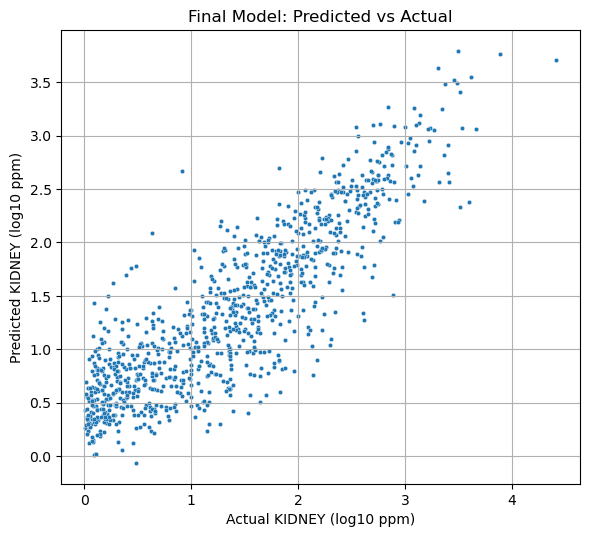

In [27]:
model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# === 7. Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
spearman_corr, _ = spearmanr(y_test, y_pred)

print("=== FINAL MODEL: XGBoost + SHAP-Inspired Features + Zero Imputation ===")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Spearman ρ: {spearman_corr:.4f}")

# === 8. Plot: Predicted vs Actual
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, s=10)
plt.xlabel("Actual KIDNEY (log10 ppm)")
plt.ylabel("Predicted KIDNEY (log10 ppm)")
plt.title("Final Model: Predicted vs Actual")
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

=== FINAL MODEL (EVALUATED IN PPM) ===
RMSE (ppm): 749.63
R² (ppm): 0.4158
MAPE: 119.67%
Spearman ρ (ppm): 0.8543


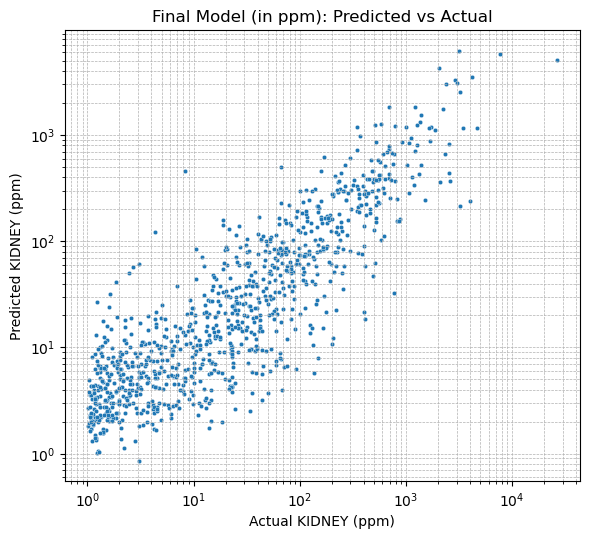

In [28]:
from sklearn.metrics import mean_absolute_percentage_error

# === 7. Invert log10 to ppm scale
y_test_ppm = 10 ** y_test
y_pred_ppm = 10 ** y_pred

# === 8. Evaluation in ppm
rmse_ppm = np.sqrt(mean_squared_error(y_test_ppm, y_pred_ppm))
r2_ppm = r2_score(y_test_ppm, y_pred_ppm)
mape_ppm = mean_absolute_percentage_error(y_test_ppm, y_pred_ppm) * 100
spearman_ppm, _ = spearmanr(y_test_ppm, y_pred_ppm)

print("=== FINAL MODEL (EVALUATED IN PPM) ===")
print(f"RMSE (ppm): {rmse_ppm:.2f}")
print(f"R² (ppm): {r2_ppm:.4f}")
print(f"MAPE: {mape_ppm:.2f}%")
print(f"Spearman ρ (ppm): {spearman_ppm:.4f}")

# === 9. Plot in ppm
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_ppm, y=y_pred_ppm, s=10)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual KIDNEY (ppm)")
plt.ylabel("Predicted KIDNEY (ppm)")
plt.title("Final Model (in ppm): Predicted vs Actual")
plt.grid(True, which='both', ls='--', lw=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()
